# 입력 feature 선택 및 Logistic Regression 모델 학습 및 검증

이전 RandomForest 실험 (`randomforest_28_allow_block_type_v1.ipynb`) 에서 allow / block 분류 성능이 매우 좋게 나왔다 (전체 recall ≈ 0.946, CAPTCHA recall ≈ 0.929, FPR ≈ 0.020). 다만 RandomForest 는 비선형 모델이라 feature 방향성 해석이 어렵고 일부 feature 의존 과적합 가능성도 확인하기 어렵다.

본 노트북은 **Logistic Regression** 을 supervised baseline 으로 추가해 다음을 검증하는 것이 목적이다.

1. 선형 모델만으로도 allow / block 이 잘 구분되는지 확인
2. BLOCK probability 분포가 type 별로 잘 분리되는지 확인 (pooled model + type 별 threshold 전략 검증)
3. coefficient 부호·크기로 BLOCK 판단에 양의 영향을 주는 feature 해석
4. RandomForest 결과와 비교할 수 있는 해석 가능한 baseline 구축

## 1. 데이터 준비

### 1.1 ⚙️ 학습 설정 (args)

In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

args = SimpleNamespace(
    RUN_VERSION="logistic_29_allow_block_type_v1",
    DATA_ROOT="../../data/data_0514_1800_v2",
    MODEL_SAVE_DIR="../model_joblib/logistic_29_allow_block_type_v1",
    RANDOM_STATE=42,
    TEST_SIZE=0.2,
    MAX_MISSING_RATE=0.3,
    USE_TYPE_AS_FEATURE=False,
    SAVE_MODEL=True,
    # Logistic Regression 고정 파라미터 (이번 노트북은 튜닝 목적이 아니므로 고정)
    LR_C=1.0,
    LR_PENALTY="l2",
    LR_SOLVER="liblinear",
    LR_CLASS_WEIGHT="balanced",
    LR_MAX_ITER=2000,
)
args

namespace(RUN_VERSION='logistic_29_allow_block_type_v1',
          DATA_ROOT='../../data/data_0514_1800_v2',
          MODEL_SAVE_DIR='../model_joblib/logistic_29_allow_block_type_v1',
          RANDOM_STATE=42,
          TEST_SIZE=0.2,
          MAX_MISSING_RATE=0.3,
          USE_TYPE_AS_FEATURE=False,
          SAVE_MODEL=True,
          LR_C=1.0,
          LR_PENALTY='l2',
          LR_SOLVER='liblinear',
          LR_CLASS_WEIGHT='balanced',
          LR_MAX_ITER=2000)

### 1.2 데이터 로드 헬퍼 함수

In [2]:
TYPE_MAP = {"booking": "BOOKING", "captcha": "CAPTCHA", "detail": "DETAIL"}
LABEL_MAP = {"allow": "ALLOW", "block": "BLOCK"}


def _match_from_parts(parts_lower, mapping):
    hits = [v for k, v in mapping.items() if k in parts_lower]
    return hits


def load_data(root_dir):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {root.resolve()}")
    rows = []
    n_total, n_skip = 0, 0
    for jp in sorted(root.rglob("*.json")):
        n_total += 1
        try:
            with open(jp, encoding="utf-8") as f:
                obj = json.load(f)
        except Exception as e:
            warnings.warn(f"skip {jp}: {e}")
            n_skip += 1
            continue
        flat = pd.json_normalize(obj, sep=".")
        parts_lower = [p.lower() for p in jp.parts]
        type_hits = _match_from_parts(parts_lower, TYPE_MAP)
        label_hits = _match_from_parts(parts_lower, LABEL_MAP)
        if len(type_hits) != 1:
            raise ValueError(f"{jp}: type matches {type_hits}")
        if len(label_hits) != 1:
            raise ValueError(f"{jp}: label matches {label_hits}")
        flat["type"] = type_hits[0]
        flat["label_norm"] = label_hits[0]
        flat["y"] = 0 if label_hits[0] == "ALLOW" else 1
        flat["source_path"] = str(jp)
        flat["source_file"] = jp.name
        rows.append(flat)
    df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    return df, n_total, n_skip

### 1.3 데이터 로드 실행 ✅

In [3]:
df_eda, n_total, n_skip = load_data(args.DATA_ROOT)
print(f"json files scanned: {n_total}, skipped: {n_skip}, loaded rows: {len(df_eda)}")
print(f"df_eda.shape: {df_eda.shape}")
print("columns (first 50):", df_eda.columns.tolist()[:50])

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25896\573298808.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


json files scanned: 707, skipped: 0, loaded rows: 707
df_eda.shape: (707, 41)
columns (first 50): ['trialId', 'label', 'type', 'metrics.reclick_rate', 'metrics.misclick_rate', 'metrics.mouse_jerk_mean', 'metrics.double_click_rate', 'metrics.mouse_overshoot_flag', 'metrics.mousemove_event_rate', 'metrics.pre_click_scroll_flag', 'metrics.time_to_first_click_ms', 'metrics.inter_click_interval_ms', 'metrics.mouse_acceleration_mean', 'metrics.mouse_speed_change_mean', 'metrics.pre_click_hover_time_ms', 'metrics.click_offset_variance_px', 'metrics.mouse_stop_segment_count', 'metrics.mouse_avg_speed_px_per_ms', 'metrics.mouse_hover_dwell_time_ms', 'metrics.mouse_max_speed_px_per_ms', 'metrics.mouse_path_curvature_mean', 'metrics.pre_click_mousemove_count', 'metrics.click_position_repeat_rate', 'metrics.mouse_direction_change_count', 'metrics.mouse_path_straightness_score', 'metrics.edge_or_fixed_point_visit_rate', 'metrics.mouse_total_travel_distance_px', 'metrics.click_sequence_consistency_s

In [4]:
print("\n[label_norm x type crosstab]")
print(pd.crosstab(df_eda["label_norm"], df_eda["type"], margins=True))

print("\n[y distribution]")
print(df_eda["y"].value_counts().sort_index())

print("\n[per-type allow/block counts]")
print(df_eda.groupby(["type", "label_norm"]).size().unstack(fill_value=0))


[label_norm x type crosstab]
type        BOOKING  CAPTCHA  DETAIL  All
label_norm                               
ALLOW            64       87      93  244
BLOCK           148      151     164  463
All             212      238     257  707

[y distribution]
y
0    244
1    463
Name: count, dtype: int64

[per-type allow/block counts]
label_norm  ALLOW  BLOCK
type                    
BOOKING        64    148
CAPTCHA        87    151
DETAIL         93    164


## 2. 데이터 전처리

### 2.1 feature 후보 선정

- 숫자형 컴럼만 후보로 사용
- y / label / 경로 / id 계열, timestamp / created_at / updated_at substring 컴럼은 제외
- `USE_TYPE_AS_FEATURE = False` → type 은 평가용 group 으로만 사용

In [5]:
EXCLUDE_EXACT = {
    "y", "label_norm", "type", "source_path", "source_file",
    "id", "trial_id", "trialId", "user_id", "session_id",
}
EXCLUDE_SUBSTR = ("timestamp", "created_at", "updated_at")


def is_excluded(col):
    if col in EXCLUDE_EXACT:
        return True
    c = col.lower()
    return any(s in c for s in EXCLUDE_SUBSTR)


numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
feature_candidates = [c for c in numeric_cols if not is_excluded(c)]

if args.USE_TYPE_AS_FEATURE:
    # 현재 default False — 사용 시에는 one-hot 별도로 추가하는 식으로 확장
    pass

print(f"numeric columns: {len(numeric_cols)}")
print(f"feature_candidates: {len(feature_candidates)}")
feature_candidates

numeric columns: 34
feature_candidates: 32


['metrics.reclick_rate',
 'metrics.misclick_rate',
 'metrics.mouse_jerk_mean',
 'metrics.double_click_rate',
 'metrics.mouse_overshoot_flag',
 'metrics.mousemove_event_rate',
 'metrics.pre_click_scroll_flag',
 'metrics.time_to_first_click_ms',
 'metrics.inter_click_interval_ms',
 'metrics.mouse_acceleration_mean',
 'metrics.mouse_speed_change_mean',
 'metrics.pre_click_hover_time_ms',
 'metrics.click_offset_variance_px',
 'metrics.mouse_avg_speed_px_per_ms',
 'metrics.mouse_hover_dwell_time_ms',
 'metrics.mouse_max_speed_px_per_ms',
 'metrics.mouse_path_curvature_mean',
 'metrics.pre_click_mousemove_count',
 'metrics.click_position_repeat_rate',
 'metrics.mouse_path_straightness_score',
 'metrics.edge_or_fixed_point_visit_rate',
 'metrics.mouse_total_travel_distance_px',
 'metrics.click_sequence_consistency_score',
 'metrics.immediate_post_render_click_rate',
 'metrics.pre_click_path_300ms_straightness',
 'metrics.pre_click_path_500ms_straightness',
 'metrics.inter_element_move_interva

### 2.2 ✅ 결측치 점검

In [6]:
missing_rate = df_eda[feature_candidates].isna().mean().sort_values(ascending=False)
print("[missing rate per feature]")
print(missing_rate.to_string())

excluded_features = [c for c in feature_candidates if missing_rate[c] > args.MAX_MISSING_RATE]
selected_features = [c for c in feature_candidates if c not in excluded_features]

print(f"\nMAX_MISSING_RATE = {args.MAX_MISSING_RATE}")
print(f"excluded_features ({len(excluded_features)}): {excluded_features}")
print(f"selected_features ({len(selected_features)}):")
for c in selected_features:
    print(f"  - {c}")

[missing rate per feature]
metrics.mouse_jerk_mean                            0.428571
metrics.inter_element_move_interval_std_ms         0.420085
metrics.click_offset_variance_px                   0.417256
metrics.inter_click_interval_ms                    0.326733
metrics.mouse_acceleration_mean                    0.216407
metrics.mouse_speed_change_mean                    0.216407
metrics.mouse_avg_speed_px_per_ms                  0.216407
metrics.mouse_max_speed_px_per_ms                  0.216407
metrics.mouse_path_straightness_score              0.216407
metrics.mouse_total_travel_distance_px             0.216407
metrics.mouse_path_curvature_mean                  0.216407
metrics.edge_or_fixed_point_visit_rate             0.216407
metrics.mouse_hover_dwell_time_ms                  0.216407
metrics.time_to_first_click_ms                     0.000000
metrics.mousemove_event_rate                       0.000000
metrics.pre_click_scroll_flag                      0.000000
metrics.pre_c

### 2.3 train / test split

In [7]:
X = df_eda[selected_features].copy()
y = df_eda["y"].copy()
groups_type = df_eda["type"].copy()

X_train, X_test, y_train, y_test, type_train, type_test = train_test_split(
    X, y, groups_type,
    test_size=args.TEST_SIZE,
    random_state=args.RANDOM_STATE,
    stratify=y,
)

print(f"X_train.shape: {X_train.shape}, X_test.shape: {X_test.shape}")
print("\n[train label distribution]")
print(y_train.value_counts().sort_index())
print("\n[test label distribution]")
print(y_test.value_counts().sort_index())
print("\n[train type distribution]")
print(type_train.value_counts())
print("\n[test type distribution]")
print(type_test.value_counts())

X_train.shape: (565, 28), X_test.shape: (142, 28)

[train label distribution]
y
0    195
1    370
Name: count, dtype: int64

[test label distribution]
y
0    49
1    93
Name: count, dtype: int64

[train type distribution]
type
DETAIL     197
CAPTCHA    195
BOOKING    173
Name: count, dtype: int64

[test type distribution]
type
DETAIL     60
CAPTCHA    43
BOOKING    39
Name: count, dtype: int64


### 2.4 전처리 파이프라인

- SimpleImputer (median) 로 결측 채움
- **Logistic Regression 은 feature scale 에 민감하므로 StandardScaler 필수**
- 모델 정의는 §3 에서 한 번에 묶어 Pipeline 구성

```python
Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(...)),
])
```

## 3. 모델 준비

이번 노트북 실행 파라미터 (args 에서 고정):

```python
LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=42,
)
```

하이퍼파라미터 후보 (이번 노트북에서는 GridSearchCV 미실행, 후속 작업용 메모):

- C: [0.01, 0.1, 1.0, 10.0]
- penalty: ["l1", "l2"]
- solver: ["liblinear", "saga", "lbfgs"]
- class_weight: [None, "balanced"]

주의:
- `l1` penalty 를 쓰려면 solver 는 `liblinear` 또는 `saga` 가 필요하다. (`lbfgs` 는 l2 만 지원)
- `liblinear` 은 small dataset 에 적합하고 l1/l2 둘 다 지원.
- 이번 기본 모델은 **l2 + liblinear** 로 고정.

In [8]:
lr_model = LogisticRegression(
    C=args.LR_C,
    penalty=args.LR_PENALTY,
    solver=args.LR_SOLVER,
    class_weight=args.LR_CLASS_WEIGHT,
    max_iter=args.LR_MAX_ITER,
    random_state=args.RANDOM_STATE,
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", lr_model),
])
pipeline

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


## 4. 모델 학습

In [9]:
t0 = time.time()
pipeline.fit(X_train, y_train)
fit_sec = time.time() - t0
print(f"학습 완료 — fit time: {fit_sec:.2f}s")
print(f"train score (accuracy): {pipeline.score(X_train, y_train):.4f}")
print(f"test  score (accuracy): {pipeline.score(X_test, y_test):.4f}")
print(f"predict_proba available: {hasattr(pipeline, 'predict_proba')}")

학습 완료 — fit time: 0.01s
train score (accuracy): 0.9681
test  score (accuracy): 0.9366
predict_proba available: True


## 5. 모델 검증

positive class = **BLOCK (y = 1)**.

### 5.1 전체 성능

In [10]:
y_pred = pipeline.predict(X_test)
y_proba_block = pipeline.predict_proba(X_test)[:, 1]


def safe_metric(fn, y_true, y_score):
    try:
        if pd.Series(y_true).nunique() < 2:
            return np.nan
        return float(fn(y_true, y_score))
    except Exception:
        return np.nan


def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return {
        "n_samples": int(len(y_true)),
        "n_allow": int((np.asarray(y_true) == 0).sum()),
        "n_block": int((np.asarray(y_true) == 1).sum()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_block_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_metric(roc_auc_score, y_true, y_score),
        "average_precision": safe_metric(average_precision_score, y_true, y_score),
        "FPR": fpr,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


overall_metrics = compute_metrics(y_test, y_pred, y_proba_block)
for k, v in overall_metrics.items():
    print(f"  {k}: {v}")

print("\n[confusion matrix]")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))
print("\n[classification report]")
print(classification_report(y_test, y_pred, target_names=["ALLOW", "BLOCK"], digits=4))

  n_samples: 142
  n_allow: 49
  n_block: 93
  accuracy: 0.9366197183098591
  precision: 0.9666666666666667
  recall_block_TPR: 0.9354838709677419
  f1: 0.9508196721311475
  roc_auc: 0.9852973447443494
  average_precision: 0.9937878030675917
  FPR: 0.061224489795918366
  tn: 46
  fp: 3
  fn: 6
  tp: 87

[confusion matrix]
[[46  3]
 [ 6 87]]

[classification report]
              precision    recall  f1-score   support

       ALLOW     0.8846    0.9388    0.9109        49
       BLOCK     0.9667    0.9355    0.9508        93

    accuracy                         0.9366       142
   macro avg     0.9256    0.9371    0.9309       142
weighted avg     0.9384    0.9366    0.9370       142



### 5.2 type 별 성능

In [11]:
TYPES = ["BOOKING", "CAPTCHA", "DETAIL"]
type_metrics_rows = []
for t in TYPES:
    mask = (type_test == t).values
    if mask.sum() == 0:
        warnings.warn(f"no test samples for type={t}")
        continue
    m = compute_metrics(
        y_test.values[mask], y_pred[mask], y_proba_block[mask]
    )
    m["type"] = t
    type_metrics_rows.append(m)

cols_order = [
    "type", "n_samples", "n_allow", "n_block",
    "accuracy", "precision", "recall_block_TPR", "f1",
    "roc_auc", "average_precision", "FPR",
    "tn", "fp", "fn", "tp",
]
df_type_metrics = pd.DataFrame(type_metrics_rows)[cols_order]
type_metrics_dict = {row["type"]: row for row in type_metrics_rows}
df_type_metrics

,type,n_samples,n_allow,n_block,accuracy,precision,recall_block_TPR,f1,roc_auc,average_precision,FPR,tn,fp,fn,tp
0,BOOKING,39,12,27,0.948718,0.962963,0.962963,0.962963,0.972222,0.990741,0.083333,11,1,1,26
1,CAPTCHA,43,15,28,0.930233,0.962963,0.928571,0.945455,0.995238,0.997493,0.066667,14,1,2,26
2,DETAIL,60,22,38,0.933333,0.972222,0.921053,0.945946,0.990431,0.994805,0.045455,21,1,3,35


### 5.3 ✅ 시각화

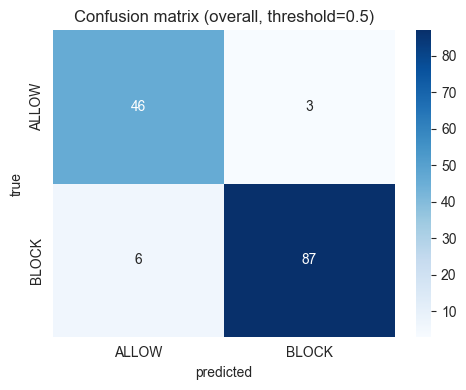

In [12]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["ALLOW", "BLOCK"], yticklabels=["ALLOW", "BLOCK"], ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix (overall, threshold=0.5)")
plt.tight_layout()
plt.show()

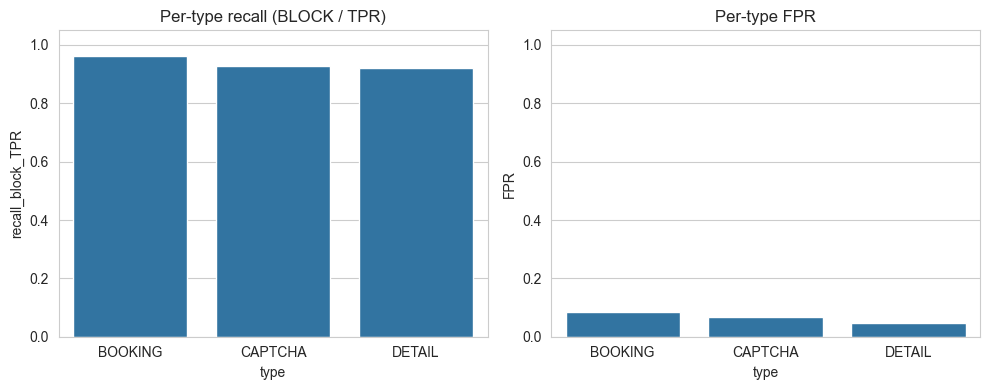

In [13]:
# Per-type recall_block_TPR & FPR barplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=df_type_metrics, x="type", y="recall_block_TPR", ax=axes[0])
axes[0].set_title("Per-type recall (BLOCK / TPR)")
axes[0].set_ylim(0, 1.05)
sns.barplot(data=df_type_metrics, x="type", y="FPR", ax=axes[1])
axes[1].set_title("Per-type FPR")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

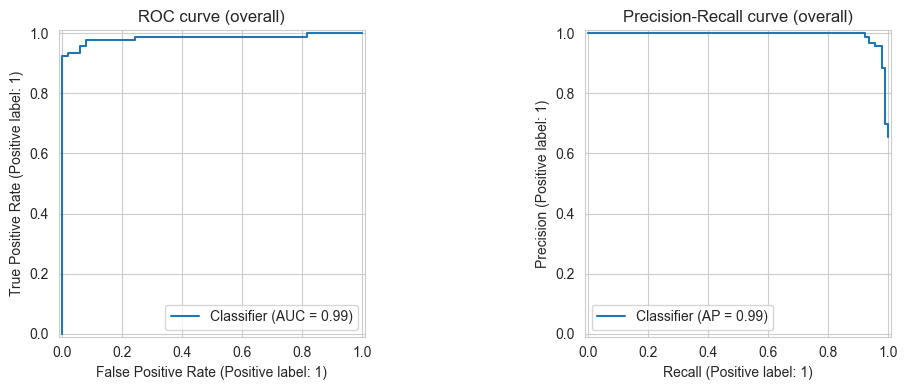

In [14]:
# ROC & Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_block, ax=axes[0])
axes[0].set_title("ROC curve (overall)")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_block, ax=axes[1])
axes[1].set_title("Precision-Recall curve (overall)")
plt.tight_layout()
plt.show()

### 5.4 ✅ Threshold sweep

`predict_proba` 의 block probability 를 사용해 threshold 별 성능을 비교한다.
후보 threshold: `[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]`.

목적: allow 오탐을 너무 키우지 않으면서 block recall 을 높일 수 있는 threshold 후보 탐색.

In [15]:
THRESHOLDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
sweep_cols = [
    "threshold", "type", "accuracy", "precision", "recall_block_TPR", "f1",
    "FPR", "tn", "fp", "fn", "tp",
]

all_rows = []
for t in THRESHOLDS:
    y_pred_t = (y_proba_block >= t).astype(int)
    m = compute_metrics(y_test.values, y_pred_t, y_proba_block)
    m["threshold"] = t
    m["type"] = "ALL"
    all_rows.append(m)
df_sweep_all = pd.DataFrame(all_rows)[sweep_cols]

print("[threshold sweep — ALL]")
df_sweep_all

[threshold sweep — ALL]


,threshold,type,accuracy,precision,recall_block_TPR,f1,FPR,tn,fp,fn,tp
0,0.2,ALL,0.943662,0.956989,0.956989,0.956989,0.081633,45,4,4,89
1,0.3,ALL,0.950704,0.967391,0.956989,0.962162,0.061224,46,3,4,89
2,0.4,ALL,0.943662,0.967033,0.946237,0.956522,0.061224,46,3,5,88
3,0.5,ALL,0.936620,0.966667,0.935484,0.950820,0.061224,46,3,6,87
4,0.6,ALL,0.936620,0.966667,0.935484,0.950820,0.061224,46,3,6,87
5,0.7,ALL,0.936620,0.966667,0.935484,0.950820,0.061224,46,3,6,87
6,0.8,ALL,0.950704,0.988636,0.935484,0.961326,0.020408,48,1,6,87


In [16]:
type_rows = []
for t in THRESHOLDS:
    y_pred_t = (y_proba_block >= t).astype(int)
    for tp_name in TYPES:
        mask = (type_test == tp_name).values
        if mask.sum() == 0:
            continue
        m = compute_metrics(
            y_test.values[mask], y_pred_t[mask], y_proba_block[mask]
        )
        m["threshold"] = t
        m["type"] = tp_name
        type_rows.append(m)
df_sweep_type = pd.DataFrame(type_rows)[sweep_cols]
print("[threshold sweep — per type]")
df_sweep_type

[threshold sweep — per type]


,threshold,type,accuracy,precision,recall_block_TPR,f1,FPR,tn,fp,fn,tp
0,0.2,BOOKING,0.923077,0.928571,0.962963,0.945455,0.166667,10,2,1,26
1,0.2,CAPTCHA,0.953488,0.964286,0.964286,0.964286,0.066667,14,1,1,27
2,0.2,DETAIL,0.950000,0.972973,0.947368,0.960000,0.045455,21,1,2,36
3,0.3,BOOKING,0.948718,0.962963,0.962963,0.962963,0.083333,11,1,1,26
4,0.3,CAPTCHA,0.953488,0.964286,0.964286,0.964286,0.066667,14,1,1,27
5,0.3,DETAIL,0.950000,0.972973,0.947368,0.960000,0.045455,21,1,2,36
6,0.4,BOOKING,0.948718,0.962963,0.962963,0.962963,0.083333,11,1,1,26
7,0.4,CAPTCHA,0.930233,0.962963,0.928571,0.945455,0.066667,14,1,2,26
8,0.4,DETAIL,0.950000,0.972973,0.947368,0.960000,0.045455,21,1,2,36
9,0.5,BOOKING,0.948718,0.962963,0.962963,0.962963,0.083333,11,1,1,26


### 5.5 Block Probability Distribution by Type

Logistic Regression 의 `predict_proba` 기반 block probability (P(y=1)) 분포를 type 별로 살펴 allow / block 분리도를 확인한다. 본 분석의 목적은 **type 별 모델이 필요하다는 의미가 아니라**, pooled Logistic Regression 모델에서 type 별 threshold 를 다르게 잡을 근거가 있는지 확인하는 것이다.

In [17]:
df_proba = pd.DataFrame({
    "y_true": y_test.values,
    "label_norm": np.where(y_test.values == 0, "ALLOW", "BLOCK"),
    "type": type_test.values,
    "proba_block": y_proba_block,
    "y_pred_0_5": (y_proba_block >= 0.5).astype(int),
})
df_proba.head()

,y_true,label_norm,type,proba_block,y_pred_0_5
0,0,ALLOW,BOOKING,0.006989,0
1,1,BLOCK,BOOKING,0.000870,0
2,0,ALLOW,CAPTCHA,0.029434,0
3,1,BLOCK,CAPTCHA,0.325849,0
4,1,BLOCK,DETAIL,0.968167,1


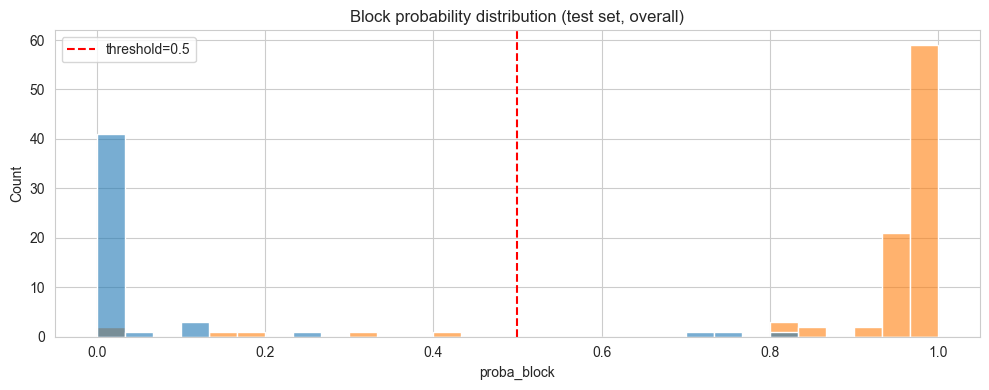

In [18]:
# 시각화 1 — 전체 test set proba_block histogram
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(
    data=df_proba, x="proba_block", hue="label_norm",
    bins=30, alpha=0.6, kde=False, ax=ax,
)
ax.axvline(0.5, ls="--", color="red", label="threshold=0.5")
ax.set_title("Block probability distribution (test set, overall)")
ax.legend()
plt.tight_layout()
plt.show()

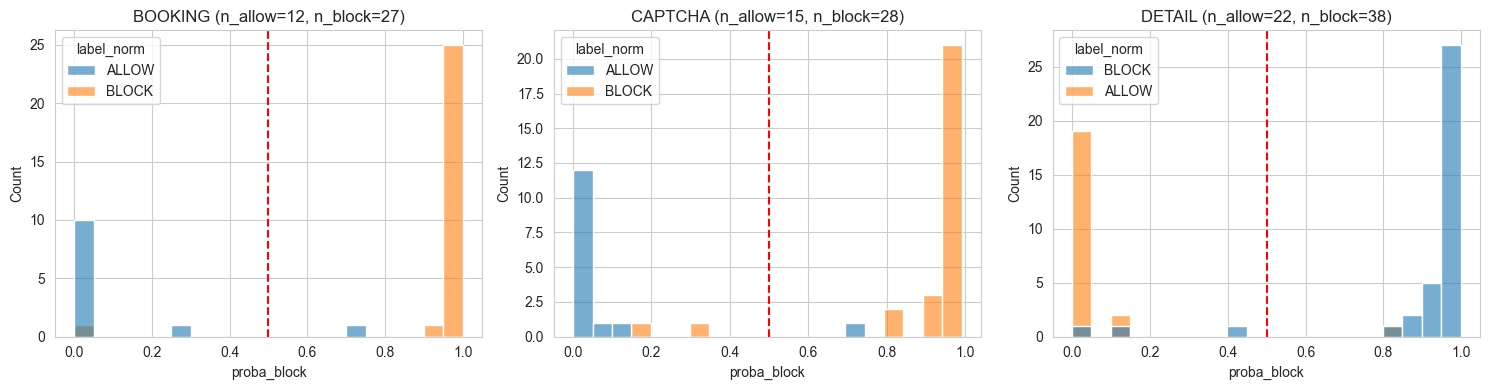

In [19]:
# 시각화 2 — type 별 subplot histogram (raw counts)
fig, axes = plt.subplots(1, len(TYPES), figsize=(5 * len(TYPES), 4), sharey=False)
for ax, t in zip(axes, TYPES):
    sub = df_proba[df_proba["type"] == t]
    sns.histplot(
        data=sub, x="proba_block", hue="label_norm",
        bins=20, alpha=0.6, kde=False, ax=ax,
    )
    ax.axvline(0.5, ls="--", color="red")
    ax.set_title(f"{t} (n_allow={(sub['label_norm']=='ALLOW').sum()}, n_block={(sub['label_norm']=='BLOCK').sum()})")
plt.tight_layout()
plt.show()

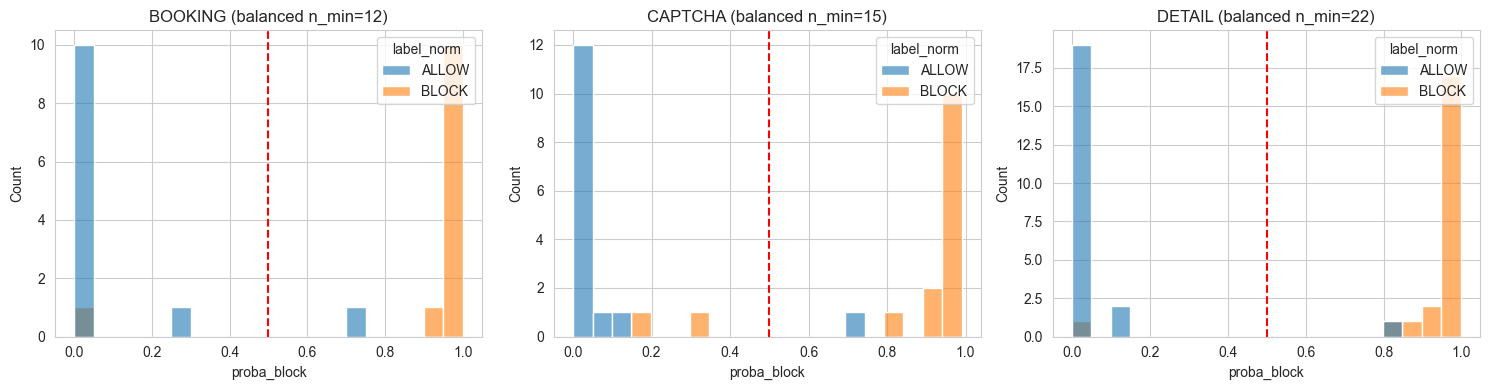

In [20]:
# 시각화 3 — type 별 1:1 balanced histogram (시각화 전용, 평가 X)
fig, axes = plt.subplots(1, len(TYPES), figsize=(5 * len(TYPES), 4), sharey=False)
for ax, t in zip(axes, TYPES):
    sub = df_proba[df_proba["type"] == t]
    a = sub[sub["label_norm"] == "ALLOW"]
    b = sub[sub["label_norm"] == "BLOCK"]
    n_min = min(len(a), len(b))
    if n_min == 0:
        ax.set_title(f"{t} (skip: n_min=0)")
        continue
    a_s = a.sample(n=n_min, random_state=args.RANDOM_STATE)
    b_s = b.sample(n=n_min, random_state=args.RANDOM_STATE)
    sub_bal = pd.concat([a_s, b_s])
    sns.histplot(
        data=sub_bal, x="proba_block", hue="label_norm",
        bins=20, alpha=0.6, kde=False, ax=ax,
    )
    ax.axvline(0.5, ls="--", color="red")
    ax.set_title(f"{t} (balanced n_min={n_min})")
plt.tight_layout()
plt.show()

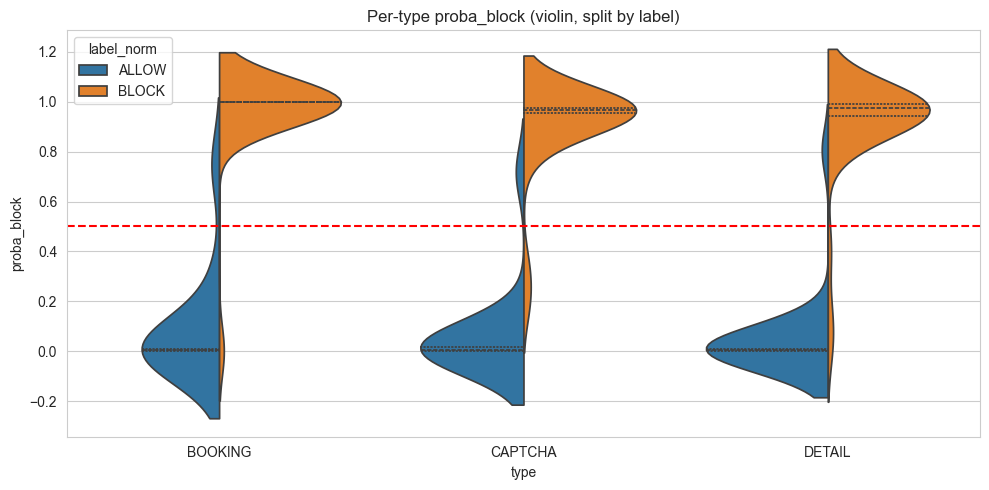

In [21]:
# 시각화 4 — type 별 violin plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_proba, x="type", y="proba_block", hue="label_norm",
    split=True, inner="quartile", ax=ax,
)
ax.axhline(0.5, ls="--", color="red")
ax.set_title("Per-type proba_block (violin, split by label)")
plt.tight_layout()
plt.show()
# 대안: boxplot 으로 보고 싶다면 아래 한 줄을 활성화하면 된다.
# sns.boxplot(data=df_proba, x="type", y="proba_block", hue="label_norm")

In [22]:
# 정량 지표 테이블 — type 별 proba_block 분포 통계
stats_rows = []
for t in TYPES:
    sub = df_proba[df_proba["type"] == t]
    a = sub[sub["label_norm"] == "ALLOW"]["proba_block"]
    b = sub[sub["label_norm"] == "BLOCK"]["proba_block"]
    n_allow, n_block = len(a), len(b)
    row = {
        "type": t,
        "n_allow": n_allow,
        "n_block": n_block,
        "allow_proba_mean": a.mean() if n_allow else np.nan,
        "block_proba_mean": b.mean() if n_block else np.nan,
        "allow_proba_median": a.median() if n_allow else np.nan,
        "block_proba_median": b.median() if n_block else np.nan,
        "allow_q75": a.quantile(0.75) if n_allow else np.nan,
        "block_q25": b.quantile(0.25) if n_block else np.nan,
    }
    row["proba_gap_mean"] = row["block_proba_mean"] - row["allow_proba_mean"]
    row["proba_gap_median"] = row["block_proba_median"] - row["allow_proba_median"]
    row["separation_margin"] = row["block_q25"] - row["allow_q75"]
    y_true_sub = sub["y_true"].values
    score_sub = sub["proba_block"].values
    if len(np.unique(y_true_sub)) > 1:
        row["roc_auc_by_type"] = float(roc_auc_score(y_true_sub, score_sub))
        row["average_precision_by_type"] = float(average_precision_score(y_true_sub, score_sub))
    else:
        row["roc_auc_by_type"] = np.nan
        row["average_precision_by_type"] = np.nan
    stats_rows.append(row)

stats_cols_order = [
    "type", "n_allow", "n_block",
    "allow_proba_mean", "block_proba_mean", "proba_gap_mean",
    "allow_proba_median", "block_proba_median", "proba_gap_median",
    "allow_q75", "block_q25", "separation_margin",
    "roc_auc_by_type", "average_precision_by_type",
]
df_proba_stats = pd.DataFrame(stats_rows)[stats_cols_order]
df_proba_stats

,type,n_allow,n_block,allow_proba_mean,block_proba_mean,proba_gap_mean,allow_proba_median,block_proba_median,proba_gap_median,allow_q75,block_q25,separation_margin,roc_auc_by_type,average_precision_by_type
0,BOOKING,12,27,0.088344,0.959779,0.871435,0.005262,0.999450,0.994188,0.008511,0.998909,0.990398,0.972222,0.990741
1,CAPTCHA,15,28,0.063514,0.907002,0.843487,0.002905,0.965897,0.962992,0.018392,0.953919,0.935528,0.995238,0.997493
2,DETAIL,22,38,0.050472,0.900667,0.850196,0.003475,0.973661,0.970186,0.007842,0.941540,0.933697,0.990431,0.994805


In [23]:
# 자동 해석 print — gap_mean 대/소 기준값은 임의 default (운영 합의 전 안)
GAP_BIG = 0.2
print(f"(기준: proba_gap_mean >= {GAP_BIG} → '대', separation_margin > 0 → 분리 양호)")
for _, row in df_proba_stats.iterrows():
    t = row["type"]
    gap = row["proba_gap_mean"]
    sep = row["separation_margin"]
    big = (not pd.isna(gap)) and gap >= GAP_BIG
    if big and (not pd.isna(sep)) and sep > 0:
        print(f"[{t}] gap_mean={gap:.3f}, separation_margin={sep:.3f} → threshold 조정 효과적일 가능성 높음")
    elif big:
        print(f"[{t}] gap_mean={gap:.3f}, separation_margin={sep:.3f} → 일부 겹침. threshold 조정 가능하나 FPR/TPR trade-off 존재")
    else:
        print(f"[{t}] gap_mean={gap:.3f}, separation_margin={sep:.3f} → 현재 feature / model 로 해당 type 분리 어려움")

(기준: proba_gap_mean >= 0.2 → '대', separation_margin > 0 → 분리 양호)
[BOOKING] gap_mean=0.871, separation_margin=0.990 → threshold 조정 효과적일 가능성 높음
[CAPTCHA] gap_mean=0.843, separation_margin=0.936 → threshold 조정 효과적일 가능성 높음
[DETAIL] gap_mean=0.850, separation_margin=0.934 → threshold 조정 효과적일 가능성 높음


## 6. Coefficient Analysis

Logistic Regression 의 핵심 장점은 **coefficient 해석**이다.

- Pipeline 에 StandardScaler 가 포함되어 있으므로 coefficient 는 **표준화된 feature 기준 영향력**으로 해석한다.
- coefficient 가 양수 → feature 값이 증가할수록 BLOCK 확률 증가 ("BLOCK+" 방향)
- coefficient 가 음수 → feature 값이 증가할수록 ALLOW 확률 증가 ("ALLOW-" 방향)

In [24]:
coef = pipeline.named_steps["model"].coef_[0]
intercept = float(pipeline.named_steps["model"].intercept_[0])

feat_coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef),
    "direction": np.where(coef >= 0, "BLOCK+", "ALLOW-"),
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

print(f"intercept: {intercept:.4f}")
print(f"\n[abs_coefficient top 20]")
feat_coef_df.head(20)

intercept: 1.2039

[abs_coefficient top 20]


,feature,coefficient,abs_coefficient,direction
0,metrics.double_click_rate,1.683906,1.683906,BLOCK+
1,metrics.mousemove_event_rate,-1.398054,1.398054,ALLOW-
2,metrics.mouse_speed_change_mean,1.368274,1.368274,BLOCK+
3,metrics.time_to_first_click_ms,-1.001578,1.001578,ALLOW-
4,metrics.mouse_acceleration_mean,-0.854859,0.854859,ALLOW-
5,metrics.pre_click_path_300ms_straightness,-0.844551,0.844551,ALLOW-
6,metrics.click_position_repeat_rate,-0.803059,0.803059,ALLOW-
7,metrics.pre_click_mousemove_count,-0.724837,0.724837,ALLOW-
8,metrics.mouse_hover_dwell_time_ms,-0.644189,0.644189,ALLOW-
9,metrics.time_from_element_visible_to_click_ms,0.613477,0.613477,BLOCK+


In [25]:
# BLOCK 방향 양의 coefficient top 15 (feature 값이 증가할수록 BLOCK 확률 증가)
pos_top = (
    feat_coef_df[feat_coef_df["coefficient"] > 0]
    .sort_values("coefficient", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
print("[positive coefficient top 15 — BLOCK 방향]")
pos_top

[positive coefficient top 15 — BLOCK 방향]


,feature,coefficient,abs_coefficient,direction
0,metrics.double_click_rate,1.683906,1.683906,BLOCK+
1,metrics.mouse_speed_change_mean,1.368274,1.368274,BLOCK+
2,metrics.time_from_element_visible_to_click_ms,0.613477,0.613477,BLOCK+
3,metrics.time_from_element_clickable_to_click_ms,0.534018,0.534018,BLOCK+
4,metrics.mouse_avg_speed_px_per_ms,0.526617,0.526617,BLOCK+
5,metrics.mouse_max_speed_px_per_ms,0.381872,0.381872,BLOCK+
6,metrics.mouse_path_curvature_mean,0.292190,0.292190,BLOCK+
7,metrics.pre_click_path_500ms_total_distance_px,0.163552,0.163552,BLOCK+
8,metrics.click_sequence_consistency_score,0.118735,0.118735,BLOCK+


In [26]:
# ALLOW 방향 음의 coefficient top 15 (feature 값이 증가할수록 ALLOW 확률 증가)
neg_top = (
    feat_coef_df[feat_coef_df["coefficient"] < 0]
    .sort_values("coefficient", ascending=True)
    .head(15)
    .reset_index(drop=True)
)
print("[negative coefficient top 15 — ALLOW 방향]")
neg_top

[negative coefficient top 15 — ALLOW 방향]


,feature,coefficient,abs_coefficient,direction
0,metrics.mousemove_event_rate,-1.398054,1.398054,ALLOW-
1,metrics.time_to_first_click_ms,-1.001578,1.001578,ALLOW-
2,metrics.mouse_acceleration_mean,-0.854859,0.854859,ALLOW-
3,metrics.pre_click_path_300ms_straightness,-0.844551,0.844551,ALLOW-
4,metrics.click_position_repeat_rate,-0.803059,0.803059,ALLOW-
5,metrics.pre_click_mousemove_count,-0.724837,0.724837,ALLOW-
6,metrics.mouse_hover_dwell_time_ms,-0.644189,0.644189,ALLOW-
7,metrics.click_offset_from_element_center_px,-0.457488,0.457488,ALLOW-
8,metrics.reclick_rate,-0.452173,0.452173,ALLOW-
9,metrics.pre_click_path_300ms_total_distance_px,-0.424832,0.424832,ALLOW-


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25896\3456077477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


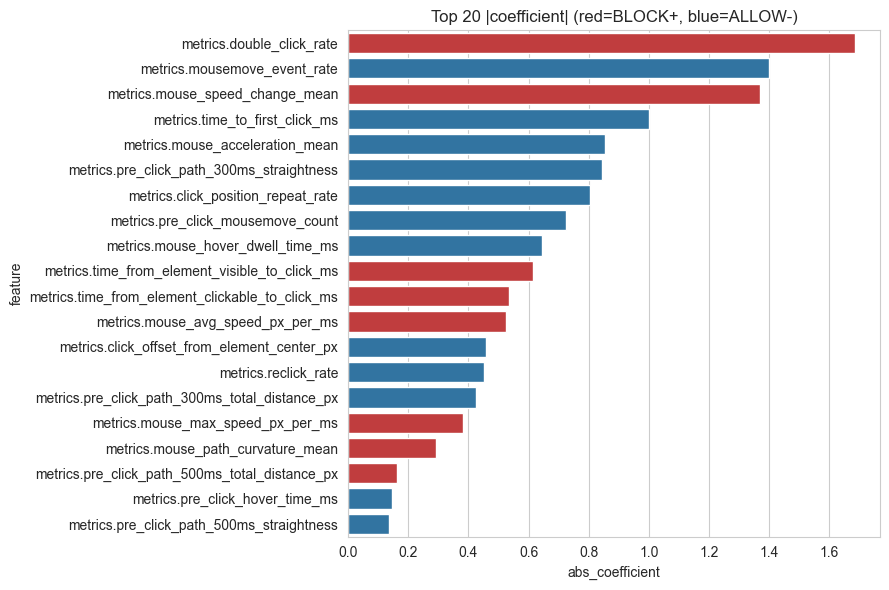

In [27]:
# abs_coefficient top 20 barplot
top20 = feat_coef_df.head(20)
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["tab:red" if d == "BLOCK+" else "tab:blue" for d in top20["direction"]]
sns.barplot(
    data=top20, y="feature", x="abs_coefficient",
    palette=colors, ax=ax,
)
ax.set_title("Top 20 |coefficient| (red=BLOCK+, blue=ALLOW-)")
plt.tight_layout()
plt.show()

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25896\179987496.py:6: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25896\179987496.py:6: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


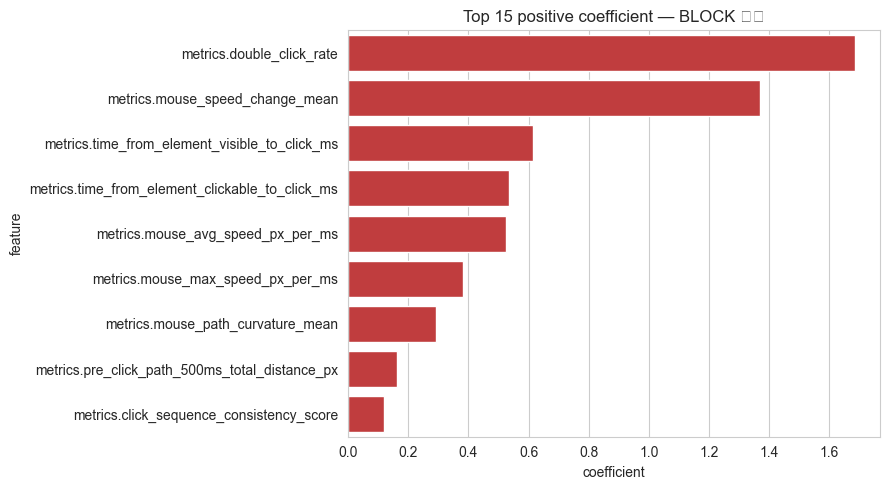

In [28]:
# Positive coefficient top 15 barplot (BLOCK 방향)
if len(pos_top) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=pos_top, y="feature", x="coefficient", color="tab:red", ax=ax)
    ax.set_title("Top 15 positive coefficient — BLOCK 방향")
    plt.tight_layout()
    plt.show()
else:
    print("positive coefficient 없음")

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25896\1276747108.py:6: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_25896\1276747108.py:6: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SSAFY\miniforge3\envs\tickle\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


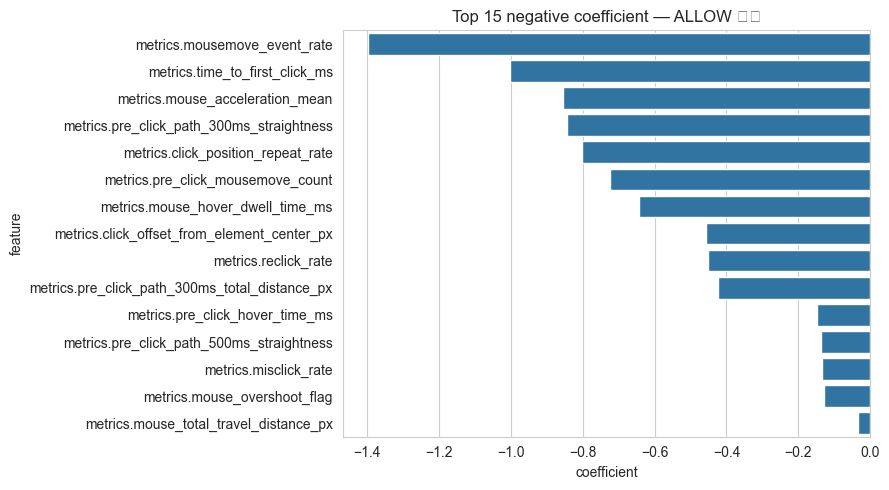

In [29]:
# Negative coefficient top 15 barplot (ALLOW 방향)
if len(neg_top) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=neg_top, y="feature", x="coefficient", color="tab:blue", ax=ax)
    ax.set_title("Top 15 negative coefficient — ALLOW 방향")
    plt.tight_layout()
    plt.show()
else:
    print("negative coefficient 없음")

## 7. 모델 저장

저장 위치: `../model_joblib/logistic_29_allow_block_type_v1/`

- `logistic_pipeline.joblib` — imputer + scaler + LogisticRegression 포함 sklearn Pipeline
- `feature_names.joblib` — `selected_features` 리스트
- `metadata.joblib` — run config, label mapping, model params, overall / type metrics, threshold sweep summary, coefficient top features

In [30]:
if args.SAVE_MODEL:
    os.makedirs(args.MODEL_SAVE_DIR, exist_ok=True)
    pipe_path = os.path.join(args.MODEL_SAVE_DIR, "logistic_pipeline.joblib")
    feat_path = os.path.join(args.MODEL_SAVE_DIR, "feature_names.joblib")
    meta_path = os.path.join(args.MODEL_SAVE_DIR, "metadata.joblib")

    joblib.dump(pipeline, pipe_path)
    joblib.dump(selected_features, feat_path)

    metadata = {
        "RUN_VERSION": args.RUN_VERSION,
        "DATA_ROOT": args.DATA_ROOT,
        "MODEL_SAVE_DIR": args.MODEL_SAVE_DIR,
        "RANDOM_STATE": args.RANDOM_STATE,
        "TEST_SIZE": args.TEST_SIZE,
        "MAX_MISSING_RATE": args.MAX_MISSING_RATE,
        "selected_features": selected_features,
        "excluded_features": excluded_features,
        "label_mapping": {"ALLOW": 0, "BLOCK": 1},
        "model_params": pipeline.named_steps["model"].get_params(),
        "overall_metrics": overall_metrics,
        "type_metrics": type_metrics_dict,
        "threshold_sweep_all": df_sweep_all.to_dict("records"),
        "threshold_sweep_type": df_sweep_type.to_dict("records"),
        "coefficient_top_features": feat_coef_df.head(20).to_dict("records"),
        "intercept": intercept,
    }
    joblib.dump(metadata, meta_path)

    print("saved:")
    print(f"  {os.path.abspath(pipe_path)}")
    print(f"  {os.path.abspath(feat_path)}")
    print(f"  {os.path.abspath(meta_path)}")
else:
    print("SAVE_MODEL=False — 모델 저장 건너뜀.")

saved:
  c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\logistic_29_allow_block_type_v1\logistic_pipeline.joblib
  c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\logistic_29_allow_block_type_v1\feature_names.joblib
  c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\logistic_29_allow_block_type_v1\metadata.joblib


## 8. 결과 리포트

자동 요약: 전체 성능 / type 별 block recall / Isolation Forest 와 RandomForest 대비 비교 / FPR / coefficient 해석 가치 / 채택 판단.

In [31]:
print("=== 1. 전체 Logistic Regression 성능 ===")
for k, v in overall_metrics.items():
    print(f"  {k}: {v}")

print("\n=== 2. type별 block recall 비교 ===")
print(df_type_metrics[["type", "recall_block_TPR", "FPR", "roc_auc", "average_precision"]].to_string(index=False))

=== 1. 전체 Logistic Regression 성능 ===
  n_samples: 142
  n_allow: 49
  n_block: 93
  accuracy: 0.9366197183098591
  precision: 0.9666666666666667
  recall_block_TPR: 0.9354838709677419
  f1: 0.9508196721311475
  roc_auc: 0.9852973447443494
  average_precision: 0.9937878030675917
  FPR: 0.061224489795918366
  tn: 46
  fp: 3
  fn: 6
  tp: 87

=== 2. type별 block recall 비교 ===
   type  recall_block_TPR      FPR  roc_auc  average_precision
BOOKING          0.962963 0.083333 0.972222           0.990741
CAPTCHA          0.928571 0.066667 0.995238           0.997493
 DETAIL          0.921053 0.045455 0.990431           0.994805


In [32]:
# 비교 기준 상수
IF_POOLED_RECALL = 0.617
IF_CAPTCHA_RECALL = 0.245
RF_OVERALL_RECALL = 0.946
RF_CAPTCHA_RECALL = 0.929
RF_FPR = 0.020
FPR_HIGH = 0.2
TYPE_RECALL_GAP_HIGH = 0.2

captcha_row = df_type_metrics[df_type_metrics["type"] == "CAPTCHA"]
captcha_recall = float(captcha_row["recall_block_TPR"].iloc[0]) if len(captcha_row) > 0 else np.nan

overall_recall = overall_metrics["recall_block_TPR"]
overall_fpr = overall_metrics["FPR"]

print("=== 3. CAPTCHA recall — Isolation Forest baseline 비교 ===")
print(f"  IF CAPTCHA recall (baseline): {IF_CAPTCHA_RECALL}")
print(f"  LR CAPTCHA recall          : {captcha_recall}")
if not np.isnan(captcha_recall) and captcha_recall > IF_CAPTCHA_RECALL:
    print("  → LR CAPTCHA recall 이 IF 보다 높음. CAPTCHA 에서도 supervised 모델이 유리.")
else:
    print("  → LR CAPTCHA recall 이 IF 대비 개선 미흡.")

print("\n=== 4. 전체 recall — Isolation Forest pooled baseline 비교 ===")
print(f"  IF pooled recall (baseline): {IF_POOLED_RECALL}")
print(f"  LR overall recall          : {overall_recall:.3f}, FPR: {overall_fpr:.3f}")
if overall_recall > IF_POOLED_RECALL:
    print("  → LR 전체 recall 이 IF pooled baseline 보다 높음 → Isolation Forest 대비 유망")
else:
    print("  → LR 전체 recall 이 IF pooled baseline 이하 → supervised 이득 제한적")

print("\n=== 5. RandomForest 와의 성능 비교 ===")
print(f"  RF overall recall: {RF_OVERALL_RECALL}, RF CAPTCHA recall: {RF_CAPTCHA_RECALL}, RF FPR: {RF_FPR}")
print(f"  LR overall recall: {overall_recall:.3f}, LR CAPTCHA recall: {captcha_recall:.3f}, LR FPR: {overall_fpr:.3f}")
if overall_recall >= RF_OVERALL_RECALL:
    print("  → LR 이 RF 와 동등 또는 더 높은 recall → 해석 가능한 선형 모델로 우수")
else:
    print("  → LR recall 이 RF 보다 낮아도 coefficient 해석 가능한 해석용 baseline 으로 가치 있음")

print("\n=== 6. FPR 높은 type 점검 ===")
high_fpr = df_type_metrics[df_type_metrics["FPR"] > FPR_HIGH]
if len(high_fpr) == 0:
    print(f"  FPR > {FPR_HIGH} 인 type 없음.")
else:
    for _, row in high_fpr.iterrows():
        print(f"  [{row['type']}] FPR={row['FPR']:.3f} > {FPR_HIGH} → threshold 조정 필요")
if not np.isnan(overall_fpr) and overall_fpr > FPR_HIGH:
    print(f"  전체 FPR {overall_fpr:.3f} > {FPR_HIGH} → threshold 조정 필요")

=== 3. CAPTCHA recall — Isolation Forest baseline 비교 ===
  IF CAPTCHA recall (baseline): 0.245
  LR CAPTCHA recall          : 0.9285714285714286
  → LR CAPTCHA recall 이 IF 보다 높음. CAPTCHA 에서도 supervised 모델이 유리.

=== 4. 전체 recall — Isolation Forest pooled baseline 비교 ===
  IF pooled recall (baseline): 0.617
  LR overall recall          : 0.935, FPR: 0.061
  → LR 전체 recall 이 IF pooled baseline 보다 높음 → Isolation Forest 대비 유망

=== 5. RandomForest 와의 성능 비교 ===
  RF overall recall: 0.946, RF CAPTCHA recall: 0.929, RF FPR: 0.02
  LR overall recall: 0.935, LR CAPTCHA recall: 0.929, LR FPR: 0.061
  → LR recall 이 RF 보다 낮아도 coefficient 해석 가능한 해석용 baseline 으로 가치 있음

=== 6. FPR 높은 type 점검 ===
  FPR > 0.2 인 type 없음.


In [33]:
print("=== 7. coefficient 기준 주요 feature top 20 (abs 기준) ===")
print(feat_coef_df.head(20)[["feature", "coefficient", "abs_coefficient", "direction"]].to_string(index=False))

print("\n=== 8. type 별 separation_margin 요약 ===")
print(df_proba_stats[["type", "proba_gap_mean", "separation_margin", "roc_auc_by_type"]].to_string(index=False))

n_sep_pos = int((df_proba_stats["separation_margin"] > 0).sum())
n_total_types = int(len(df_proba_stats))
print(f"\nseparation_margin > 0 type: {n_sep_pos}/{n_total_types}")
if n_sep_pos == n_total_types:
    print("  → 모든 type 에서 분포 분리 양호 → pooled model + type별 threshold 전략 가능")
elif n_sep_pos > 0:
    print("  → 일부 type 분리 양호 → 해당 type 은 threshold 조정 유망, 나머지 type 은 특징 보강 필요")
else:
    print("  → 분포 분리 부족 → 현재 feature/model 로는 pooled + type별 threshold 전략 제한적")

=== 7. coefficient 기준 주요 feature top 20 (abs 기준) ===
                                        feature  coefficient  abs_coefficient direction
                      metrics.double_click_rate     1.683906         1.683906    BLOCK+
                   metrics.mousemove_event_rate    -1.398054         1.398054    ALLOW-
                metrics.mouse_speed_change_mean     1.368274         1.368274    BLOCK+
                 metrics.time_to_first_click_ms    -1.001578         1.001578    ALLOW-
                metrics.mouse_acceleration_mean    -0.854859         0.854859    ALLOW-
      metrics.pre_click_path_300ms_straightness    -0.844551         0.844551    ALLOW-
             metrics.click_position_repeat_rate    -0.803059         0.803059    ALLOW-
              metrics.pre_click_mousemove_count    -0.724837         0.724837    ALLOW-
              metrics.mouse_hover_dwell_time_ms    -0.644189         0.644189    ALLOW-
  metrics.time_from_element_visible_to_click_ms     0.613477       

In [34]:
# 최종 채택 판단
recall_max_minus_min = float(df_type_metrics["recall_block_TPR"].max() - df_type_metrics["recall_block_TPR"].min())

print("=== 9. Logistic Regression 채택 판단 ===")
print(f"  overall recall (BLOCK / TPR): {overall_recall:.3f}")
print(f"  overall FPR                 : {overall_fpr:.3f}")
print(f"  type별 recall max-min       : {recall_max_minus_min:.3f}")
print(f"  (참고) IF pooled recall: {IF_POOLED_RECALL}, IF CAPTCHA recall: {IF_CAPTCHA_RECALL}")
print(f"  (참고) RF overall recall: {RF_OVERALL_RECALL}, RF CAPTCHA recall: {RF_CAPTCHA_RECALL}, RF FPR: {RF_FPR}")

verdicts = []
if not np.isnan(captcha_recall) and captcha_recall > IF_CAPTCHA_RECALL:
    verdicts.append(f"CAPTCHA recall {captcha_recall:.3f} > IF {IF_CAPTCHA_RECALL} → CAPTCHA 에서도 supervised 모델이 유리")
if overall_recall > IF_POOLED_RECALL and (np.isnan(overall_fpr) or overall_fpr <= FPR_HIGH):
    verdicts.append(
        f"overall recall {overall_recall:.3f} > IF pooled {IF_POOLED_RECALL} & FPR {overall_fpr:.3f} ≤ {FPR_HIGH} "
        "→ Logistic Regression baseline 이 Isolation Forest 대비 유망"
    )
if overall_recall < RF_OVERALL_RECALL:
    verdicts.append(
        f"overall recall {overall_recall:.3f} < RF {RF_OVERALL_RECALL} "
        "→ RF 보다 성능은 낮아도 coefficient 해석 가능 → 해석용 baseline 으로 유용"
    )
else:
    verdicts.append(
        f"overall recall {overall_recall:.3f} ≥ RF {RF_OVERALL_RECALL} "
        "→ 선형 모델만으로도 RF 수준 성능 + 해석 가능"
    )
if not np.isnan(overall_fpr) and overall_fpr > FPR_HIGH:
    verdicts.append(f"overall FPR {overall_fpr:.3f} > {FPR_HIGH} → threshold 조정 필요")
if recall_max_minus_min > TYPE_RECALL_GAP_HIGH:
    verdicts.append(
        f"type별 recall 편차 {recall_max_minus_min:.3f} > {TYPE_RECALL_GAP_HIGH} "
        "→ type별 threshold 또는 type별 feature 재검토 필요"
    )
if n_sep_pos == n_total_types:
    verdicts.append("모든 type separation_margin > 0 → pooled model + type별 threshold 전략 가능")

print()
if not verdicts:
    print("  (자동 판단 룰에 걸린 항목 없음 — 수동 검토 권장)")
for v in verdicts:
    print(f"  - {v}")

print("\n[coefficient 상위 feature — RF importance 로와 교차 확인용]")
for _, row in feat_coef_df.head(10).iterrows():
    print(f"  {row['direction']:7s}  coef={row['coefficient']:+.4f}  {row['feature']}")

=== 9. Logistic Regression 채택 판단 ===
  overall recall (BLOCK / TPR): 0.935
  overall FPR                 : 0.061
  type별 recall max-min       : 0.042
  (참고) IF pooled recall: 0.617, IF CAPTCHA recall: 0.245
  (참고) RF overall recall: 0.946, RF CAPTCHA recall: 0.929, RF FPR: 0.02

  - CAPTCHA recall 0.929 > IF 0.245 → CAPTCHA 에서도 supervised 모델이 유리
  - overall recall 0.935 > IF pooled 0.617 & FPR 0.061 ≤ 0.2 → Logistic Regression baseline 이 Isolation Forest 대비 유망
  - overall recall 0.935 < RF 0.946 → RF 보다 성능은 낮아도 coefficient 해석 가능 → 해석용 baseline 으로 유용
  - 모든 type separation_margin > 0 → pooled model + type별 threshold 전략 가능

[coefficient 상위 feature — RF importance 로와 교차 확인용]
  BLOCK+   coef=+1.6839  metrics.double_click_rate
  ALLOW-   coef=-1.3981  metrics.mousemove_event_rate
  BLOCK+   coef=+1.3683  metrics.mouse_speed_change_mean
  ALLOW-   coef=-1.0016  metrics.time_to_first_click_ms
  ALLOW-   coef=-0.8549  metrics.mouse_acceleration_mean
  ALLOW-   coef=-0.8446  metrics.pre_click_p